# Classificação de especialidades médicas: do CSV às métricas

Este notebook reúne os passos para **preparar os dados, treinar um modelo,
avaliar os resultados e prever o conjunto de teste**. Executa-o de cima para
baixo com **Restart Kernel and Run All Cells** / **Run All**.

Não é necessário executar primeiro `01_preparacao_dados.ipynb`. A reparação
estrutural reutiliza `data_preparation.py`; os modelos estão em `models.py`.
Os parâmetros que podes alterar estão concentrados na secção 2.

**Percurso:** ambiente → configuração → reparação → exploração → preparação do
texto → folds → modelos e TF-IDF → treino → métricas globais → comparação dos campos → métricas por
classe → matrizes de confusão → erros → modelo final → previsões.

As métricas usam previsões **fora do treino**: cada caso é previsto por um modelo
que não foi treinado nessa linha. `test_no_labels.csv` não tem rótulos, por isso
serve para gerar previsões; não permite calcular accuracy, precision, recall ou F1.


## 1. Ambiente e localização do projeto

Na pasta `help-the-doctors`, antes da primeira execução:

```powershell
python -m venv .venv
.\.venv\Scripts\python.exe -m pip install -r requirements.txt
.\.venv\Scripts\python.exe -m jupyter lab
```

Em VS Code, seleciona `.venv` como kernel deste notebook. A célula seguinte
encontra o projeto tanto a partir da sua pasta como da pasta `LN`.


In [1]:
from pathlib import Path
import importlib.metadata as metadata
import json
import sys
import time

candidates = [Path.cwd(), *Path.cwd().parents]
candidates += [path / "help-the-doctors" for path in candidates.copy()]
ROOT = next(
    (path for path in candidates
     if (path / "data_preparation.py").is_file() and (path / "train.csv").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Abre o notebook a partir de LN ou de help-the-doctors.")
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

from config import (
    LABEL, MIN_ACCURACY, MIN_CLASS_F1,
    N_FOLDS as DEFAULT_N_FOLDS, SEED as DEFAULT_SEED,
)
from data import text_input
from data_preparation import (
    COLUMNS, audit_records, export_reader, export_results,
    repair_training_csv, sha256,
)
from models import logistic_regression, naive_bayes
from read_test_set import EXPECTED_TEST_CASES, TEST_COLUMNS, read_test_cases, write_results

pd.set_option("display.max_colwidth", 110)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
versions = {package: metadata.version(package) for package in (
    "pandas", "scikit-learn", "numpy", "matplotlib", "joblib", "ipykernel"
)}
print(f"Projeto: {ROOT}\nPython: {sys.executable}")
display(pd.Series({"python": sys.version.split()[0], **versions}, name="Versão").to_frame())


Projeto: D:\projetos\faculdade\LN\help-the-doctors
Python: D:\projetos\faculdade\LN\help-the-doctors\.venv\Scripts\python.exe


,Versão
python,3.14.3
pandas,3.0.6
scikit-learn,1.9.1
numpy,2.5.3
matplotlib,3.11.2
joblib,1.6.0
ipykernel,7.4.0


## 2. Configuração da experiência

Altera esta célula e volta a executar **todas** as seguintes.

- `TEXT_FIELDS`: campos usados pela regressão logística. `keywords` está excluído
  porque começa pela especialidade do caso e revela o rótulo.
- `MAIN_MODEL`: `"Regressão logística"` ou `"Naive Bayes (descrição)"`.
- `CV_MODE`: `"stratified"` reproduz os folds aleatórios dos scripts atuais;
  `"grouped"` mantém cada grupo de transcrições repetidas no mesmo fold.
- `COMPARE_BASELINES`: inclui a classe mais frequente e o Naive Bayes na comparação.
- `COMPARE_LR_FIELDS`: testa cada campo, cada par e os três juntos com regressão logística.
- `NGRAM_RANGE`: `(1, 1)` usa palavras; `(1, 2)` inclui pares de palavras.
- `C`: valores menores dão mais regularização à regressão logística.

O modelo principal é escolhido explicitamente. Os resultados servem para
comparar experiências; escolher parâmetros repetidamente com estes mesmos folds
pode tornar a estimativa otimista. Uma seleção rigorosa exige validação independente
ou validação cruzada aninhada.


In [2]:
TEXT_FIELDS = ("description", "sample_name", "transcription")
MAIN_MODEL = "Regressão logística"
CV_MODE = "stratified"  # "grouped" para manter transcrições repetidas juntas
N_FOLDS = DEFAULT_N_FOLDS
SEED = DEFAULT_SEED
COMPARE_BASELINES = True
COMPARE_LR_FIELDS = True  # comparar os 7 conjuntos de campos com o mesmo modelo

NGRAM_RANGE = (1, 2)
MIN_DF = 2
SUBLINEAR_TF = True
C = 1.0
CLASS_WEIGHT = "balanced"
MAX_ITER = 2000
NB_ALPHA = 1.0
NB_FIT_PRIOR = True

OUTPUT_DIR = ROOT / "outputs" / "notebook"
WRITE_ROOT_RESULTS = False  # True também escreve o results.txt da raiz
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

allowed_fields = {"description", "sample_name", "transcription"}
if not TEXT_FIELDS or len(set(TEXT_FIELDS)) != len(TEXT_FIELDS):
    raise ValueError("Escolhe pelo menos um campo de texto, sem repetições.")
if set(TEXT_FIELDS) - allowed_fields:
    raise ValueError("Usa description, sample_name e/ou transcription; keywords revela a classe.")
if MAIN_MODEL not in {"Regressão logística", "Naive Bayes (descrição)"}:
    raise ValueError("MAIN_MODEL tem de ser um dos dois modelos indicados acima.")
if CV_MODE not in {"stratified", "grouped"}:
    raise ValueError("CV_MODE tem de ser stratified ou grouped.")
if not isinstance(N_FOLDS, int) or N_FOLDS < 2:
    raise ValueError("N_FOLDS tem de ser um inteiro >= 2.")

print(f"Modelo principal: {MAIN_MODEL} | CV: {CV_MODE} | Folds: {N_FOLDS} | Seed: {SEED}")
print(f"Campos da regressão logística: {', '.join(TEXT_FIELDS)}")
print(f"Resultados: {OUTPUT_DIR}")


Modelo principal: Regressão logística | CV: stratified | Folds: 5 | Seed: 0
Campos da regressão logística: description, sample_name, transcription
Resultados: D:\projetos\faculdade\LN\help-the-doctors\outputs\notebook


## 3. Ler, reparar e auditar os dados originais

O `train.csv` contém aspas incompletas, colunas vazias excedentes e continuações
de transcrição. Uma leitura direta com `pd.read_csv` não substitui esta reparação.
As funções do projeto preservam os casos, os rótulos e o texto disponível,
assinalam campos vazios e repetições e geram o CSV reparado e a auditoria.

Os casos incompletos e os rótulos ambíguos são mantidos. A célula também recria
o leitor HTML, útil para consultar os textos completos. O conjunto de teste só
será lido na secção 14; aqui é guardado o hash para verificar a integridade.


In [3]:
original_hashes = {name: sha256(ROOT / name) for name in ("train.csv", "test_no_labels.csv")}
records, changes = repair_training_csv(ROOT / "train.csv")
audit_rows = audit_records(records)
preparation_summary = export_results(ROOT, records, changes, audit_rows)
reader_path = export_reader(ROOT, records, audit_rows, preparation_summary)

train = pd.DataFrame(records).reset_index(drop=True)
audit = pd.DataFrame(audit_rows).reset_index(drop=True)
assert train["record_id"].equals(audit["record_id"])
assert train[LABEL].notna().all()
CLASS_ORDER = sorted(train[LABEL].unique())

display(pd.Series({
    "Casos": len(train),
    "Especialidades": len(CLASS_ORDER),
    "Casos reparados": int(audit["is_repaired"].sum()),
    "Casos parciais": int(audit["is_partial"].sum()),
    "Casos com transcrição repetida": int(audit["duplicate_group_id"].ne("").sum()),
    "Casos com transcrição e rótulos em conflito": int(audit["conflicting_labels"].sum()),
}, name="Quantidade").to_frame())
display(train[["record_id", *COLUMNS]].head(3))
display(pd.DataFrame(changes).head(8))
print(f"CSV reparado: {ROOT / preparation_summary['clean_file']}")
print(f"Leitor dos textos completos: {reader_path}")


,Quantidade
Casos,2669
Especialidades,12
Casos reparados,13
Casos parciais,11
Casos com transcrição repetida,1530
Casos com transcrição e rótulos em conflito,1528


,record_id,medical_specialty,description,sample_name,transcription,keywords
0,1,Cardiovascular-Pulmonary,"Chest pain, possible syncopal spells. She has been having multiple cardiovascular complaints including c...",Chest Pain - Cardiac Consult,"REASON FOR REFERRAL: Chest pain, possible syncopal spells.,She is a very pleasant 31-year-old mother of t...","cardiovascular / pulmonary, chest pain, syncopal, echocardiogram, ekg, cardiac etiology, syncopal spells, ..."
1,2,Cardiovascular-Pulmonary,"The patient is 14 months old, comes in with a chief complaint of difficulty breathing.",Difficulty Breathing - ER Visit,"HISTORY: The patient is 14 months old, comes in with a chief complaint of difficulty breathing. Difficul...",
2,3,Cardiovascular-Pulmonary,"Fiberoptic bronchoscopy, diagnostic. Hemoptysis and history of lung cancer. Tumor occluding right middl...",Fiberoptic Bronchoscopy - 1,"PREOPERATIVE DIAGNOSIS:1. Hemoptysis.,2. History of lung cancer.,POSTOPERATIVE DIAGNOSIS: Tumor occludi...","cardiovascular / pulmonary, hemoptysis, lung cancer, tumor, fiberoptic, bronchoscopy, endoscopy suite, ade..."


,record_id,source_line,action,details
0,160,161,close_truncated_description,"Fechada a aspa da descrição e representados como vazios os três campos indisponíveis: sample_name, transcr..."
1,162,163,remove_extra_empty_fields,Removidos apenas os dois campos vazios excedentes após os cinco campos esperados.
2,713,714,close_truncated_description,"Fechada a aspa da descrição e representados como vazios os três campos indisponíveis: sample_name, transcr..."
3,946,947,close_truncated_description,"Fechada a aspa da descrição e representados como vazios os três campos indisponíveis: sample_name, transcr..."
4,960,961,remove_extra_empty_fields,Removidos apenas os dois campos vazios excedentes após os cinco campos esperados.
5,960,962,join_transcription_continuation,Continuação ligada ao caso anterior com uma quebra de linha. Preservados os caracteres disponíveis; não fo...
6,1086,1088,close_truncated_description,"Fechada a aspa da descrição e representados como vazios os três campos indisponíveis: sample_name, transcr..."
7,1094,1096,remove_extra_empty_fields,Removidos apenas os dois campos vazios excedentes após os cinco campos esperados.


CSV reparado: D:\projetos\faculdade\LN\help-the-doctors\data\processed\train_clean.csv
Leitor dos textos completos: D:\projetos\faculdade\LN\help-the-doctors\outputs\dados-legiveis\ler_dataset_clean.html


## 4. Explorar classes, campos vazios e qualidade dos dados

**Support** é o número de casos de cada classe. Com classes muito diferentes
em tamanho, uma boa accuracy pode esconder resultados fracos nas classes pequenas.
É por isso que também vamos olhar para F1 macro e métricas por classe.


,support,proporção
medical_specialty,,
Cardiovascular-Pulmonary,309,11.6%
Dermatology,25,0.9%
Gastroenterology,195,7.3%
General Medicine,212,7.9%
Neurology,184,6.9%
Neurosurgery,79,3.0%
Obstetrics-Gynecology,136,5.1%
Ophthalmology,73,2.7%
Orthopedic,300,11.2%


,vazios,caracteres_mediana,proporção_vazios
description,1,121,0.0%
sample_name,7,26,0.3%
transcription,31,2595,1.2%
keywords,450,180,16.9%


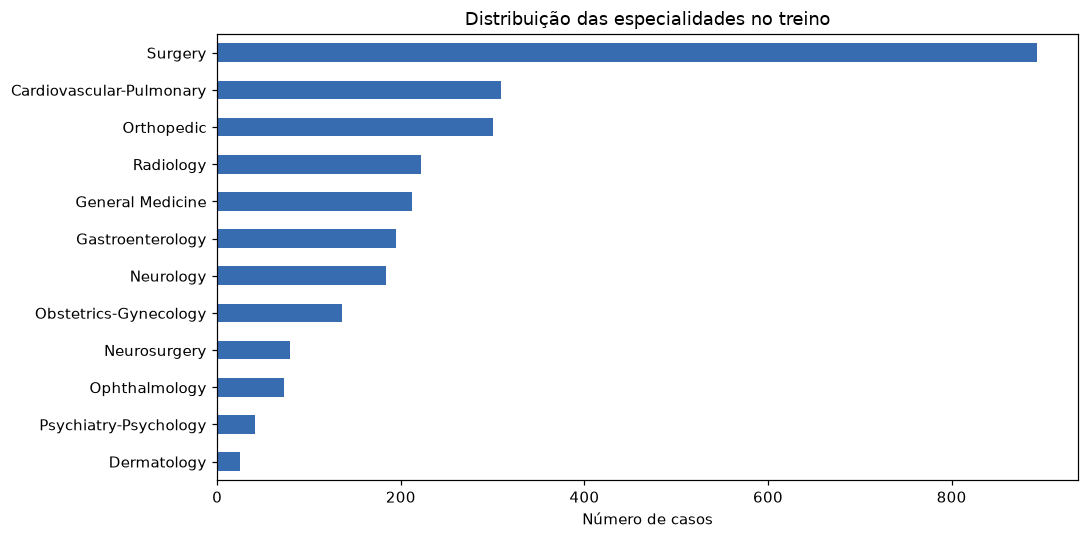

Grupos de transcrição repetida: 731
Grupos com rótulos diferentes: 730


,record_id,medical_specialty,duplicate_record_ids,group_labels
3,4,Cardiovascular-Pulmonary,4;1716,Cardiovascular-Pulmonary;Radiology
8,9,Cardiovascular-Pulmonary,9;1718,Cardiovascular-Pulmonary;Radiology
9,10,Cardiovascular-Pulmonary,10;1759,Cardiovascular-Pulmonary;Radiology
11,12,Cardiovascular-Pulmonary,12;1945,Cardiovascular-Pulmonary;Surgery
12,13,Cardiovascular-Pulmonary,13;2171,Cardiovascular-Pulmonary;Surgery
14,15,Cardiovascular-Pulmonary,15;2523,Cardiovascular-Pulmonary;Surgery


In [4]:
class_counts = train[LABEL].value_counts().reindex(CLASS_ORDER)
class_distribution = pd.DataFrame({"support": class_counts, "proporção": class_counts / len(train)})
display(class_distribution.style.format({"proporção": "{:.1%}"}))

field_quality = pd.DataFrame({
    "vazios": {field: int(train[field].fillna("").str.strip().eq("").sum()) for field in COLUMNS[1:]},
    "caracteres_mediana": {field: train[field].fillna("").str.len().median() for field in COLUMNS[1:]},
})
field_quality["proporção_vazios"] = field_quality["vazios"] / len(train)
display(field_quality.style.format({"proporção_vazios": "{:.1%}", "caracteres_mediana": "{:.0f}"}))

fig, ax = plt.subplots(figsize=(10, 5))
class_counts.sort_values().plot.barh(ax=ax, color="#386cb0")
ax.set(xlabel="Número de casos", ylabel="", title="Distribuição das especialidades no treino")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()

conflicting_examples = audit.loc[audit["conflicting_labels"], [
    "record_id", LABEL, "duplicate_record_ids", "group_labels"
]]
print(f"Grupos de transcrição repetida: {preparation_summary['duplicate_transcription_groups']}")
print(f"Grupos com rótulos diferentes: {preparation_summary['conflicting_label_groups']}")
display(conflicting_examples.head(6))


## 5. Preparar a entrada e o alvo

`X` contém os campos de texto e `y` contém `medical_specialty`, o alvo.
Preenchemos campos em falta com strings vazias e uniformizamos espaços e quebras
de linha apenas numa cópia usada pelo modelo. Estas operações não aprendem
estatísticas do corpus e podem ser aplicadas antes dos folds.

A conversão para minúsculas e a tokenização ficam no TF-IDF. Usamos o tokenizador
padrão: sequências de letras/dígitos com pelo menos dois caracteres. Não aplicamos
stemming nem remoção automática de stopwords nesta experiência, para manter um
percurso simples e não remover termos clínicos por regras adicionais.

Cada campo tem um TF-IDF próprio; isto preserva o peso dos campos curtos face às
transcrições longas. Vocabulário, IDF e filtragem por frequência serão aprendidos
**só no treino de cada fold**, dentro da Pipeline.


In [5]:
def prepare_text(frame, fields):
    # Limpeza determinística; não aprende vocabulário nem usa rótulos.
    return frame.loc[:, list(fields)].fillna("").astype(str).apply(
        lambda column: column.str.replace(r"\s+", " ", regex=True).str.strip()
    )

X = prepare_text(train, TEXT_FIELDS)
y = train[LABEL].astype(str)
# O baseline usa sempre a descrição, como o classify.py atual.
X_nb = text_input(prepare_text(train, ("description",)), ("description",))

empty_inputs = X.apply(lambda column: column.eq("")).all(axis=1)
print(f"X: {X.shape} | y: {y.shape} | Entradas inteiramente vazias: {empty_inputs.sum()}")
print("Os casos vazios são mantidos; não são removidos para melhorar as métricas.")
preview = X.head(3).apply(lambda column: column.str.slice(0, 160))
display(preview)


X: (2669, 3) | y: (2669,) | Entradas inteiramente vazias: 0
Os casos vazios são mantidos; não são removidos para melhorar as métricas.


,description,sample_name,transcription
0,"Chest pain, possible syncopal spells. She has been having multiple cardiovascular complaints including che...",Chest Pain - Cardiac Consult,"REASON FOR REFERRAL: Chest pain, possible syncopal spells.,She is a very pleasant 31-year-old mother of tw..."
1,"The patient is 14 months old, comes in with a chief complaint of difficulty breathing.",Difficulty Breathing - ER Visit,"HISTORY: The patient is 14 months old, comes in with a chief complaint of difficulty breathing. Difficulty..."
2,"Fiberoptic bronchoscopy, diagnostic. Hemoptysis and history of lung cancer. Tumor occluding right middle l...",Fiberoptic Bronchoscopy - 1,"PREOPERATIVE DIAGNOSIS:1. Hemoptysis.,2. History of lung cancer.,POSTOPERATIVE DIAGNOSIS: Tumor occluding ..."


## 6. Criar os folds de treino e validação

Em cada fold, o modelo treina nas outras partes e prevê a parte reservada para
validação. No fim, cada linha tem exatamente uma previsão **out-of-fold (OOF)**.
Todos os modelos usam os mesmos folds, permitindo uma comparação consistente.

`stratified` mantém aproximadamente as proporções das classes. Transcrições
repetidas podem aparecer dos dois lados, tal como no protocolo dos scripts.
A coluna `grupos_partilhados` torna essa sobreposição visível; este protocolo
não mede exclusivamente a generalização a notas novas.

`grouped` usa os grupos de transcrições idênticas (após retirar espaços exteriores)
da auditoria, mantendo-os no mesmo fold, mesmo que tenham rótulos diferentes.
Transcrições vazias recebem grupos individuais. O equilíbrio das classes é
aproximado; estes grupos não identificam pacientes nem agrupam textos apenas semelhantes.


In [6]:
if class_counts.min() < N_FOLDS:
    raise ValueError(f"A classe mais pequena tem {class_counts.min()} casos; reduz N_FOLDS.")

groups = audit["duplicate_group_id"].where(
    audit["duplicate_group_id"].ne(""), "record-" + train["record_id"].astype(str)
)
if CV_MODE == "grouped":
    groups_per_class = pd.DataFrame({"classe": y, "grupo": groups}).groupby("classe")["grupo"].nunique()
    if groups_per_class.min() < N_FOLDS:
        raise ValueError("Há classes com menos grupos que folds; reduz N_FOLDS.")
    splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    folds = list(splitter.split(X, y, groups))
else:
    splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    folds = list(splitter.split(X, y))

fold_assignment = np.zeros(len(y), dtype=int)
validation_visits = np.zeros(len(y), dtype=int)
split_rows = []
for fold, (train_idx, validation_idx) in enumerate(folds, start=1):
    assert set(train_idx).isdisjoint(validation_idx)
    assert len(train_idx) + len(validation_idx) == len(y)
    assert set(y.iloc[train_idx]) == set(CLASS_ORDER), "Falta uma classe no treino de um fold."
    shared = set(groups.iloc[train_idx]) & set(groups.iloc[validation_idx])
    if CV_MODE == "grouped":
        assert not shared, "Um grupo aparece no treino e na validação."
    fold_assignment[validation_idx] = fold
    validation_visits[validation_idx] += 1
    split_rows.append({
        "fold": fold, "treino": len(train_idx), "validação": len(validation_idx),
        "classes_na_validação": y.iloc[validation_idx].nunique(),
        "grupos_partilhados": len(shared),
        "casos_validação_com_grupo_no_treino": int(groups.iloc[validation_idx].isin(shared).sum()),
    })
assert np.all(validation_visits == 1), "Cada caso tem de ser validado exatamente uma vez."
split_summary = pd.DataFrame(split_rows).set_index("fold")
display(split_summary)
split_summary.to_csv(OUTPUT_DIR / "folds.csv", sep=";", encoding="utf-8-sig")


,treino,validação,classes_na_validação,grupos_partilhados,casos_validação_com_grupo_no_treino
fold,,,,,
1,2135,534,12,245,252
2,2135,534,12,254,263
3,2135,534,12,238,247
4,2135,534,12,244,249
5,2136,533,12,238,250


## 7. Definir os modelos e a representação TF-IDF

Comparamos três abordagens:

- **Classe mais frequente:** referência simples, sem aprender a partir do texto.
- **Naive Bayes (descrição):** o modelo existente em `models.py`, com contagens,
  TF-IDF e `MultinomialNB`. Usa sempre apenas `description`.
- **Regressão logística:** um `TfidfVectorizer` por campo, seguido de um classificador
  linear. `class_weight="balanced"` dá mais peso aos erros nas classes pequenas.

TF-IDF atribui pesos aos termos: termos recorrentes num caso e pouco comuns nos
outros recebem mais peso. Com `SUBLINEAR_TF=True`, as contagens positivas usam
`1 + log(contagem)`. O IDF é suavizado e cada campo de cada documento é normalizado
para norma L2 igual a 1, exceto quando não tem termos conhecidos.

`MIN_DF=2` exclui termos presentes em menos de dois documentos do **treino do fold**.
Palavras novas na validação ou no teste são ignoradas. O diagrama da Pipeline abaixo
mostra a transformação e o classificador que serão ajustados juntos.


In [7]:
lr_pipeline = logistic_regression(
    fields=TEXT_FIELDS, ngram_range=NGRAM_RANGE, min_df=MIN_DF,
    sublinear_tf=SUBLINEAR_TF, C=C, class_weight=CLASS_WEIGHT,
    max_iter=MAX_ITER, random_state=SEED,
)
nb_pipeline = naive_bayes(alpha=NB_ALPHA, fit_prior=NB_FIT_PRIOR)
available_models = {
    "Regressão logística": (lr_pipeline, X),
    "Naive Bayes (descrição)": (nb_pipeline, X_nb),
}
experiments = {}
if COMPARE_BASELINES:
    experiments["Classe mais frequente"] = (DummyClassifier(strategy="most_frequent"), X)
    experiments["Naive Bayes (descrição)"] = available_models["Naive Bayes (descrição)"]
experiments[MAIN_MODEL] = available_models[MAIN_MODEL]
main_pipeline, main_input = available_models[MAIN_MODEL]
display(main_pipeline)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('description', ...), ('sample_name', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: fl

## 8. Treinar e recolher previsões de validação cruzada

Cada `fit` ajusta uma Pipeline nova e vê apenas as linhas de treino desse fold.
As métricas são calculadas na validação, nunca nas previsões do próprio treino.
Esta célula pode demorar alguns minutos; imprime o progresso por modelo e fold.

Precision, recall e F1 usam `zero_division=0`: se o modelo nunca prevê uma classe,
a precision dessa classe é apresentada como 0. Os gráficos seguintes ajudam
a identificar esse comportamento.


In [8]:
def global_metrics(actual, predicted):
    scores = {
        "accuracy": accuracy_score(actual, predicted),
        "balanced_accuracy": balanced_accuracy_score(actual, predicted),
    }
    for average in ("macro", "weighted"):
        scores[f"precision_{average}"] = precision_score(
            actual, predicted, labels=CLASS_ORDER, average=average, zero_division=0
        )
        scores[f"recall_{average}"] = recall_score(
            actual, predicted, labels=CLASS_ORDER, average=average, zero_division=0
        )
        scores[f"f1_{average}"] = f1_score(
            actual, predicted, labels=CLASS_ORDER, average=average, zero_division=0
        )
    scores["min_f1"] = f1_score(
        actual, predicted, labels=CLASS_ORDER, average=None, zero_division=0
    ).min()
    return scores

oof_predictions = {}
fold_metric_rows = []
comparison_rows = []
first_fold_model = None
for name, (pipeline, model_input) in experiments.items():
    started = time.perf_counter()
    predictions = np.full(len(y), "", dtype=object)
    for fold, (train_idx, validation_idx) in enumerate(folds, start=1):
        fold_started = time.perf_counter()
        fitted = clone(pipeline)
        fitted.fit(model_input.iloc[train_idx], y.iloc[train_idx])
        fold_predictions = fitted.predict(model_input.iloc[validation_idx])
        predictions[validation_idx] = fold_predictions
        metrics = global_metrics(y.iloc[validation_idx], fold_predictions)
        fold_metric_rows.append({"modelo": name, "fold": fold, **metrics})
        print(
            f"{name} | fold {fold}/{N_FOLDS} | accuracy={metrics['accuracy']:.1%} "
            f"| F1 macro={metrics['f1_macro']:.1%} | {time.perf_counter() - fold_started:.1f}s",
            flush=True,
        )
        if name == MAIN_MODEL and fold == 1:
            first_fold_model = fitted
    assert np.all(predictions != "")
    assert set(predictions) <= set(CLASS_ORDER)
    oof_predictions[name] = predictions
    comparison_rows.append({
        "modelo": name, **global_metrics(y, predictions),
        "segundos": time.perf_counter() - started,
    })

comparison = pd.DataFrame(comparison_rows).set_index("modelo")
fold_metrics = pd.DataFrame(fold_metric_rows)
predicted = oof_predictions[MAIN_MODEL]
main_scores = global_metrics(y, predicted)
metric_columns = list(main_scores)
print(f"Concluído: {len(y)} previsões OOF por modelo, com CV_MODE={CV_MODE}.")


Classe mais frequente | fold 1/5 | accuracy=33.5% | F1 macro=4.2% | 0.0s


Classe mais frequente | fold 2/5 | accuracy=33.5% | F1 macro=4.2% | 0.0s


Classe mais frequente | fold 3/5 | accuracy=33.3% | F1 macro=4.2% | 0.0s


Classe mais frequente | fold 4/5 | accuracy=33.3% | F1 macro=4.2% | 0.0s


Classe mais frequente | fold 5/5 | accuracy=33.6% | F1 macro=4.2% | 0.0s


Naive Bayes (descrição) | fold 1/5 | accuracy=37.6% | F1 macro=11.3% | 0.1s


Naive Bayes (descrição) | fold 2/5 | accuracy=38.0% | F1 macro=12.0% | 0.1s


Naive Bayes (descrição) | fold 3/5 | accuracy=38.0% | F1 macro=12.2% | 0.1s


Naive Bayes (descrição) | fold 4/5 | accuracy=39.5% | F1 macro=14.1% | 0.1s


Naive Bayes (descrição) | fold 5/5 | accuracy=39.0% | F1 macro=13.8% | 0.1s

Regressão logística | fold 1/5 | accuracy=44.9% | F1 macro=48.3% | 10.1s


Regressão logística | fold 2/5 | accuracy=44.6% | F1 macro=47.1% | 10.0s


Regressão logística | fold 3/5 | accuracy=45.7% | F1 macro=46.3% | 9.4s


Regressão logística | fold 4/5 | accuracy=45.1% | F1 macro=45.4% | 8.1s


Regressão logística | fold 5/5 | accuracy=44.5% | F1 macro=50.2% | 9.2s


Concluído: 2669 previsões OOF por modelo, com CV_MODE=stratified.


### Inspecionar o TF-IDF aprendido no primeiro fold

O exemplo abaixo usa uma Pipeline já ajustada no **treino do primeiro fold**.
Mostra o tamanho do vocabulário e os termos com maior peso para um caso desse
treino. Não ajustamos um vocabulário sobre todo o dataset antes da avaliação.


In [9]:
example_idx = int(folds[0][0][0])
vocabulary_rows, weighted_terms = [], []
if MAIN_MODEL == "Regressão logística":
    for field, vectorizer, _ in first_fold_model["features"].transformers_:
        if field == "remainder":
            continue
        terms = vectorizer.get_feature_names_out()
        values = vectorizer.transform(X[field].iloc[[example_idx]]).tocsr()
        vocabulary_rows.append({"campo": field, "termos_no_vocabulário": len(terms)})
        strongest = np.argsort(values.data)[::-1][:8]
        weighted_terms.extend({
            "campo": field, "termo": terms[values.indices[position]],
            "peso_TF_IDF": float(values.data[position]),
        } for position in strongest)
else:
    terms = first_fold_model["counts"].get_feature_names_out()
    values = first_fold_model[:-1].transform(X_nb.iloc[[example_idx]]).tocsr()
    vocabulary_rows.append({"campo": "description", "termos_no_vocabulário": len(terms)})
    strongest = np.argsort(values.data)[::-1][:8]
    weighted_terms.extend({
        "campo": "description", "termo": terms[values.indices[position]],
        "peso_TF_IDF": float(values.data[position]),
    } for position in strongest)
display(pd.DataFrame(vocabulary_rows))
print(f"Exemplo: record_id={train.loc[example_idx, 'record_id']} | Classe real: {y.iloc[example_idx]}")
display(pd.DataFrame(weighted_terms, columns=["campo", "termo", "peso_TF_IDF"]).round(4))


,campo,termos_no_vocabulário
0,description,10608
1,sample_name,1522
2,transcription,120338


Exemplo: record_id=1 | Classe real: Cardiovascular-Pulmonary


,campo,termo,peso_TF_IDF
0,description,like,0.3213
1,description,which,0.2145
2,description,sometimes,0.2089
3,description,spells,0.2089
4,description,complaints including,0.2089
5,description,feel,0.2089
6,description,having multiple,0.2089
7,description,dull,0.2010
8,sample_name,cardiac consult,0.5339
9,sample_name,chest pain,0.4979


## 9. Resultados globais e comparação dos modelos

- **Accuracy:** proporção de casos cuja classe foi prevista corretamente.
- **Precision macro:** média da precision das classes, dando o mesmo peso a cada uma.
- **Recall macro / balanced accuracy:** média da fração de casos recuperados por classe.
- **F1 macro:** média do F1 das classes; penaliza resultados fracos nas classes pequenas.
- **Weighted:** média ponderada pelo número de casos de cada classe.
- **Min F1:** F1 da classe com o resultado mais baixo.

A tabela principal calcula as métricas sobre **todas as previsões OOF juntas**.
A média e o desvio padrão por fold descrevem a variação entre partições; não são
intervalos de confiança nem têm de coincidir com as métricas OOF agregadas.
No caso de classificação de uma única classe por caso, recall weighted coincide
com accuracy. Todos os valores de métricas estão entre 0 e 1 e são mostrados em percentagem.


In [10]:
display(Markdown(f"**Protocolo:** `{CV_MODE}` · **Folds:** {N_FOLDS} · **Modelo principal:** {MAIN_MODEL}"))
display(comparison.style.format({**{column: "{:.1%}" for column in metric_columns}, "segundos": "{:.1f}"}))
display(pd.Series(main_scores, name="OOF — modelo principal").to_frame().style.format("{:.1%}"))

main_fold_metrics = fold_metrics.loc[fold_metrics["modelo"].eq(MAIN_MODEL)].set_index("fold")
display(main_fold_metrics[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].style.format("{:.1%}"))
fold_variation = main_fold_metrics[metric_columns].agg(["mean", "std"]).T
display(fold_variation.style.format("{:.1%}"))

passes = main_scores["accuracy"] > MIN_ACCURACY and main_scores["min_f1"] >= MIN_CLASS_F1
print(f"Critérios em config.py: accuracy > {MIN_ACCURACY:.0%} e F1 de todas as classes >= {MIN_CLASS_F1:.0%}.")
print(f"Nesta validação cruzada: {'cumpre' if passes else 'não cumpre'} os dois critérios.")
print("Este resultado de validação não é uma avaliação do teste sem rótulos.")


**Protocolo:** `stratified` · **Folds:** 5 · **Modelo principal:** Regressão logística

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,min_f1,segundos
modelo,,,,,,,,,,
Classe mais frequente,33.5%,8.3%,2.8%,8.3%,4.2%,11.2%,33.5%,16.8%,0.0%,0.2
Naive Bayes (descrição),38.4%,13.6%,20.0%,13.6%,12.8%,31.4%,38.4%,27.7%,0.0%,0.4
Regressão logística,45.0%,51.7%,45.8%,51.7%,47.6%,46.8%,45.0%,44.2%,20.8%,46.8


,OOF — modelo principal
accuracy,45.0%
balanced_accuracy,51.7%
precision_macro,45.8%
recall_macro,51.7%
f1_macro,47.6%
precision_weighted,46.8%
recall_weighted,45.0%
f1_weighted,44.2%
min_f1,20.8%


,accuracy,precision_macro,recall_macro,f1_macro
fold,,,,
1,44.9%,45.7%,53.5%,48.3%
2,44.6%,46.7%,51.8%,47.1%
3,45.7%,44.2%,50.6%,46.3%
4,45.1%,47.1%,49.2%,45.4%
5,44.5%,50.1%,53.4%,50.2%


,mean,std
accuracy,45.0%,0.5%
balanced_accuracy,51.7%,1.8%
precision_macro,46.8%,2.2%
recall_macro,51.7%,1.8%
f1_macro,47.5%,1.9%
precision_weighted,47.2%,0.4%
recall_weighted,45.0%,0.5%
f1_weighted,44.2%,0.3%
min_f1,18.3%,5.4%


Critérios em config.py: accuracy > 49% e F1 de todas as classes >= 25%.
Nesta validação cruzada: não cumpre os dois critérios.
Este resultado de validação não é uma avaliação do teste sem rótulos.


### 9.1. Que campos funcionam melhor com regressão logística?

Comparamos **description**, **sample_name** e **transcription**, cada um sozinho,
todos os pares e os três juntos. Aqui o classificador, os pesos de classe, os
parâmetros TF-IDF, a seed e os folds são os mesmos em todas as experiências;
apenas o conjunto de campos muda. Cada campo mantém o seu próprio TF-IDF.

As métricas são calculadas sobre as previsões OOF agregadas. Olha para accuracy,
F1 macro e o menor F1: o conjunto que vence numa métrica pode perder noutra.
Esta comparação estima o efeito dos campos nesta configuração fixa; não é uma
pesquisa dos melhores parâmetros para cada conjunto de campos.

Os resultados detalhados, métricas por classe/fold e previsões ficam em
`outputs/comparacao_campos_lr/`. Podes repetir a comparação fora do notebook com
`python compare_logistic_fields.py`. Com `COMPARE_LR_FIELDS=False`, esta etapa é
omitida. Quando ativa, acrescenta alguns minutos à execução.


LR | description | fold 1/5 | accuracy=41.0% | F1 macro=43.2%


LR | description | fold 2/5 | accuracy=42.9% | F1 macro=44.2%


LR | description | fold 3/5 | accuracy=42.5% | F1 macro=42.5%


LR | description | fold 4/5 | accuracy=43.4% | F1 macro=42.1%


LR | description | fold 5/5 | accuracy=44.8% | F1 macro=49.5%


LR | sample_name | fold 1/5 | accuracy=46.4% | F1 macro=48.1%


LR | sample_name | fold 2/5 | accuracy=43.4% | F1 macro=46.4%


LR | sample_name | fold 3/5 | accuracy=44.4% | F1 macro=43.7%


LR | sample_name | fold 4/5 | accuracy=46.8% | F1 macro=48.2%


LR | sample_name | fold 5/5 | accuracy=44.5% | F1 macro=48.0%


LR | transcription | fold 1/5 | accuracy=42.9% | F1 macro=45.3%


LR | transcription | fold 2/5 | accuracy=43.6% | F1 macro=46.4%


LR | transcription | fold 3/5 | accuracy=46.4% | F1 macro=46.8%


LR | transcription | fold 4/5 | accuracy=44.4% | F1 macro=45.9%


LR | transcription | fold 5/5 | accuracy=48.0% | F1 macro=54.4%


LR | description + sample_name | fold 1/5 | accuracy=44.4% | F1 macro=48.1%


LR | description + sample_name | fold 2/5 | accuracy=45.7% | F1 macro=48.2%


LR | description + sample_name | fold 3/5 | accuracy=44.6% | F1 macro=44.8%


LR | description + sample_name | fold 4/5 | accuracy=47.0% | F1 macro=47.8%


LR | description + sample_name | fold 5/5 | accuracy=44.1% | F1 macro=48.8%


LR | description + transcription | fold 1/5 | accuracy=44.6% | F1 macro=47.1%


LR | description + transcription | fold 2/5 | accuracy=43.4% | F1 macro=45.5%


LR | description + transcription | fold 3/5 | accuracy=44.9% | F1 macro=45.8%


LR | description + transcription | fold 4/5 | accuracy=43.6% | F1 macro=44.3%


LR | description + transcription | fold 5/5 | accuracy=46.5% | F1 macro=51.3%


LR | sample_name + transcription | fold 1/5 | accuracy=45.3% | F1 macro=49.5%


LR | sample_name + transcription | fold 2/5 | accuracy=46.3% | F1 macro=49.2%


LR | sample_name + transcription | fold 3/5 | accuracy=47.8% | F1 macro=48.1%


LR | sample_name + transcription | fold 4/5 | accuracy=46.8% | F1 macro=47.6%


LR | sample_name + transcription | fold 5/5 | accuracy=45.8% | F1 macro=50.4%


LR | description + sample_name + transcription | fold 1/5 | accuracy=44.9% | F1 macro=48.3%


LR | description + sample_name + transcription | fold 2/5 | accuracy=44.6% | F1 macro=47.1%


LR | description + sample_name + transcription | fold 3/5 | accuracy=45.7% | F1 macro=46.3%


LR | description + sample_name + transcription | fold 4/5 | accuracy=45.1% | F1 macro=45.4%


LR | description + sample_name + transcription | fold 5/5 | accuracy=44.5% | F1 macro=50.2%


,accuracy,precision_macro,recall_macro,f1_macro,min_f1,worst_class,zero_f1_classes,meets_criteria
fields,,,,,,,,
description,42.9%,42.3%,50.7%,44.7%,23.5%,Neurosurgery,0,False
sample_name,45.1%,43.3%,54.2%,46.7%,23.7%,Dermatology,0,False
transcription,45.1%,46.2%,52.9%,47.9%,23.9%,Radiology,0,False
description + sample_name,45.1%,44.9%,52.8%,47.6%,25.4%,Neurosurgery,0,False
description + transcription,44.6%,46.0%,50.8%,47.0%,20.1%,Neurosurgery,0,False
sample_name + transcription,46.4%,46.5%,53.9%,49.0%,25.5%,Radiology,0,False
description + sample_name + transcription,45.0%,45.8%,51.7%,47.6%,20.8%,Neurosurgery,0,False


Maior accuracy: sample_name + transcription
Maior F1 macro: sample_name + transcription
Maior F1 mínimo: sample_name + transcription


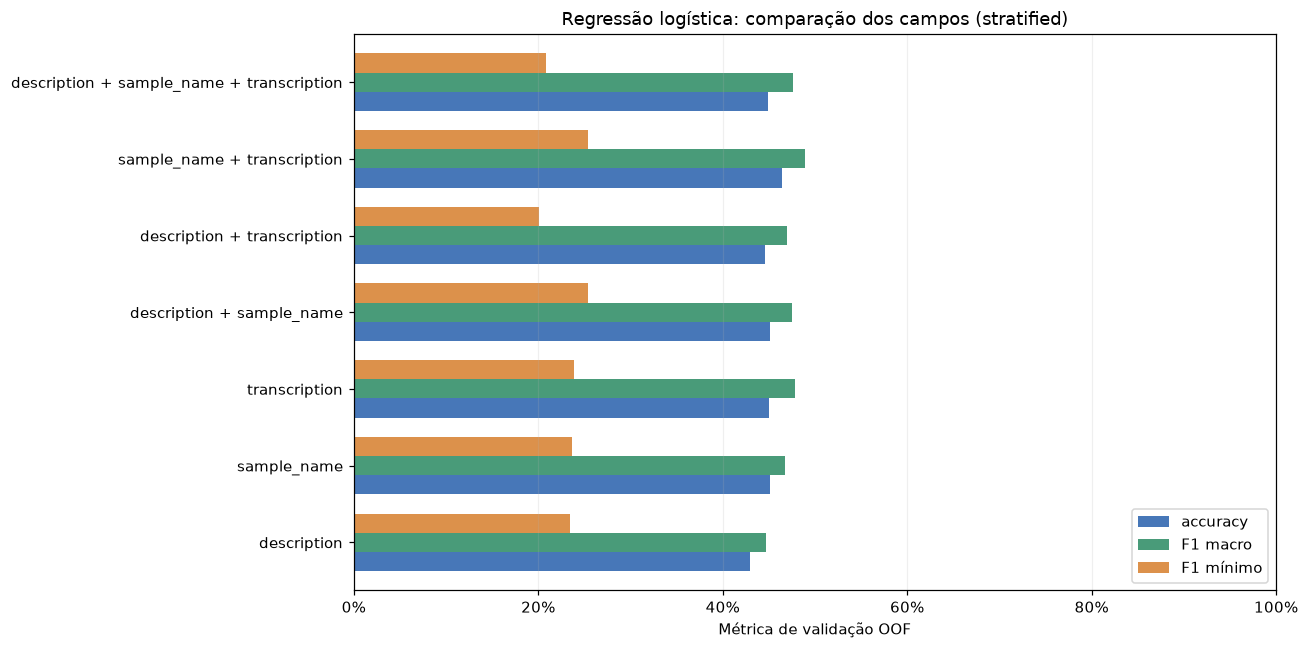

In [11]:
if COMPARE_LR_FIELDS:
    from compare_logistic_fields import compare_logistic_fields

    field_results = compare_logistic_fields(
        train, splits=folds, n_folds=N_FOLDS, seed=SEED, cv_mode=CV_MODE,
        ngram_range=NGRAM_RANGE, min_df=MIN_DF, sublinear_tf=SUBLINEAR_TF,
        C=C, class_weight=CLASS_WEIGHT, max_iter=MAX_ITER,
        output_dir=ROOT / "outputs" / "comparacao_campos_lr",
    )
    field_comparison = field_results["comparison"]
    score_columns = [column for column in field_comparison.columns if column in {
        "accuracy", "precision_macro", "recall_macro", "f1_macro", "min_f1"
    }]
    display(field_comparison[[*score_columns, "worst_class", "zero_f1_classes", "meets_criteria"]].style.format(
        {column: "{:.1%}" for column in score_columns}
    ))
    print(f"Maior accuracy: {field_comparison['accuracy'].idxmax()}")
    print(f"Maior F1 macro: {field_comparison['f1_macro'].idxmax()}")
    print(f"Maior F1 mínimo: {field_comparison['min_f1'].idxmax()}")

    fig, ax = plt.subplots(figsize=(12, 6))
    field_comparison[["accuracy", "f1_macro", "min_f1"]].rename(columns={
        "f1_macro": "F1 macro", "min_f1": "F1 mínimo"
    }).plot.barh(ax=ax, color=["#4777b8", "#499b79", "#dc914b"], width=0.75)
    ax.set(xlim=(0, 1), xlabel="Métrica de validação OOF", ylabel="",
           title=f"Regressão logística: comparação dos campos ({CV_MODE})")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(axis="x", alpha=0.2)
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(ROOT / "outputs" / "comparacao_campos_lr" / "comparacao_campos.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Comparação dos campos omitida: COMPARE_LR_FIELDS=False.")


## 10. Precision, recall, F1 e accuracy por classe

Para cada classe, tratamos os seus casos como positivos e os das outras como negativos:

- **TP:** classe real e prevista iguais à classe em análise.
- **FP:** o modelo prevê esta classe, mas a classe real é outra.
- **FN:** a classe real é esta, mas o modelo prevê outra.
- **TN:** classe real e previsão pertencem às outras classes.
- **Precision = TP / (TP + FP)**: das previsões desta classe, quantas estavam certas?
- **Recall = TP / (TP + FN)**: dos casos desta classe, quantos foram encontrados?
- **F1 = 2 × precision × recall / (precision + recall)**.
- **Accuracy OvR = (TP + TN) / total**: accuracy ao distinguir esta classe de todas as outras.

Accuracy OvR pode ser alta só porque existem muitos negativos. Para comparar
especialidades, olha sobretudo para precision, recall, F1 e support.


,precision,recall,f1,accuracy_ovr,specificity,support,previstos,TP,FP,FN,TN
classe,,,,,,,,,,,
Cardiovascular-Pulmonary,43.5%,52.1%,47.4%,86.6%,91.1%,309,370,161,209,148,2151
Dermatology,47.8%,44.0%,45.8%,99.0%,99.5%,25,23,11,12,14,2632
Gastroenterology,46.6%,62.6%,53.4%,92.0%,94.3%,195,262,122,140,73,2334
General Medicine,63.7%,81.1%,71.4%,94.8%,96.0%,212,270,172,98,40,2359
Neurology,36.8%,40.8%,38.7%,91.1%,94.8%,184,204,75,129,109,2356
Neurosurgery,16.2%,29.1%,20.8%,93.4%,95.4%,79,142,23,119,56,2471
Obstetrics-Gynecology,44.9%,64.7%,53.0%,94.2%,95.7%,136,196,88,108,48,2425
Ophthalmology,54.1%,80.8%,64.8%,97.6%,98.1%,73,109,59,50,14,2546
Orthopedic,39.2%,46.3%,42.4%,85.9%,90.9%,300,355,139,216,161,2153


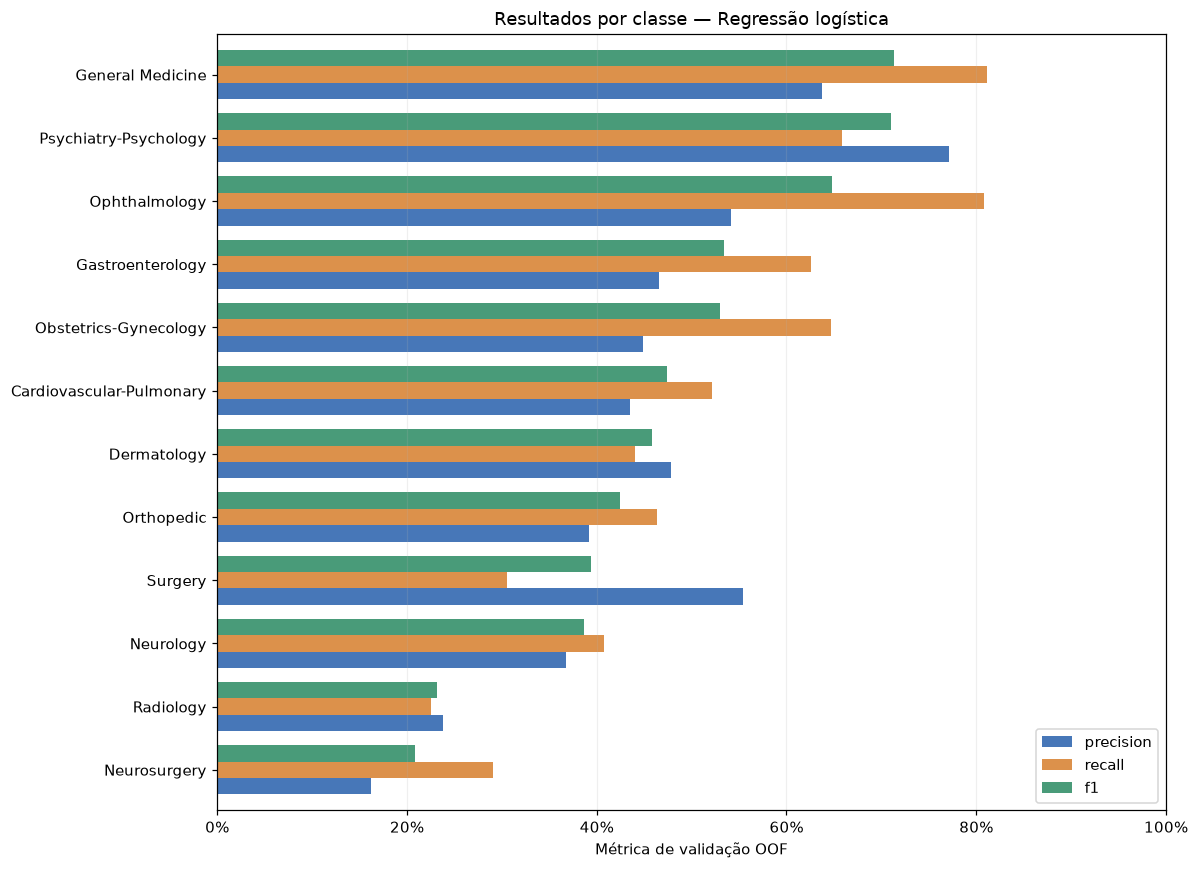

Menor F1: Neurosurgery (20.8%).
Classes nunca previstas: nenhuma


In [12]:
report_dict = classification_report(
    y, predicted, labels=CLASS_ORDER, output_dict=True, zero_division=0
)
per_class = pd.DataFrame({label: report_dict[label] for label in CLASS_ORDER}).T
per_class = per_class.rename(columns={"f1-score": "f1"})
per_class.index.name = "classe"
per_class["support"] = per_class["support"].astype(int)

cm = confusion_matrix(y, predicted, labels=CLASS_ORDER)
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = cm.sum() - tp - fp - fn
per_class["previstos"] = cm.sum(axis=0)
per_class["TP"], per_class["FP"] = tp, fp
per_class["FN"], per_class["TN"] = fn, tn
per_class["accuracy_ovr"] = (tp + tn) / cm.sum()
per_class["specificity"] = np.divide(tn, tn + fp, out=np.zeros(len(tn), dtype=float), where=(tn + fp) != 0)
per_class = per_class[[
    "precision", "recall", "f1", "accuracy_ovr", "specificity",
    "support", "previstos", "TP", "FP", "FN", "TN",
]]
display(per_class.style.format({
    column: "{:.1%}" for column in ("precision", "recall", "f1", "accuracy_ovr", "specificity")
}))

fig, ax = plt.subplots(figsize=(11, 8))
per_class.sort_values("f1")[["precision", "recall", "f1"]].plot.barh(
    ax=ax, color=["#4777b8", "#dc914b", "#499b79"], width=0.78
)
ax.set(xlim=(0, 1), xlabel="Métrica de validação OOF", ylabel="", title=f"Resultados por classe — {MAIN_MODEL}")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "metricas_por_classe.png", dpi=150, bbox_inches="tight")
plt.show()

worst_class = per_class["f1"].idxmin()
print(f"Menor F1: {worst_class} ({per_class.loc[worst_class, 'f1']:.1%}).")
never_predicted = per_class.index[per_class["previstos"].eq(0)].tolist()
print(f"Classes nunca previstas: {never_predicted or 'nenhuma'}")


## 11. Matrizes de confusão e erros mais frequentes

As **linhas são as classes reais** e as **colunas são as previsões**. A diagonal
contém os acertos. A primeira matriz mostra contagens; a segunda é normalizada
por linha e mostra as proporções dentro de cada classe real. A sua diagonal é
o recall por classe.


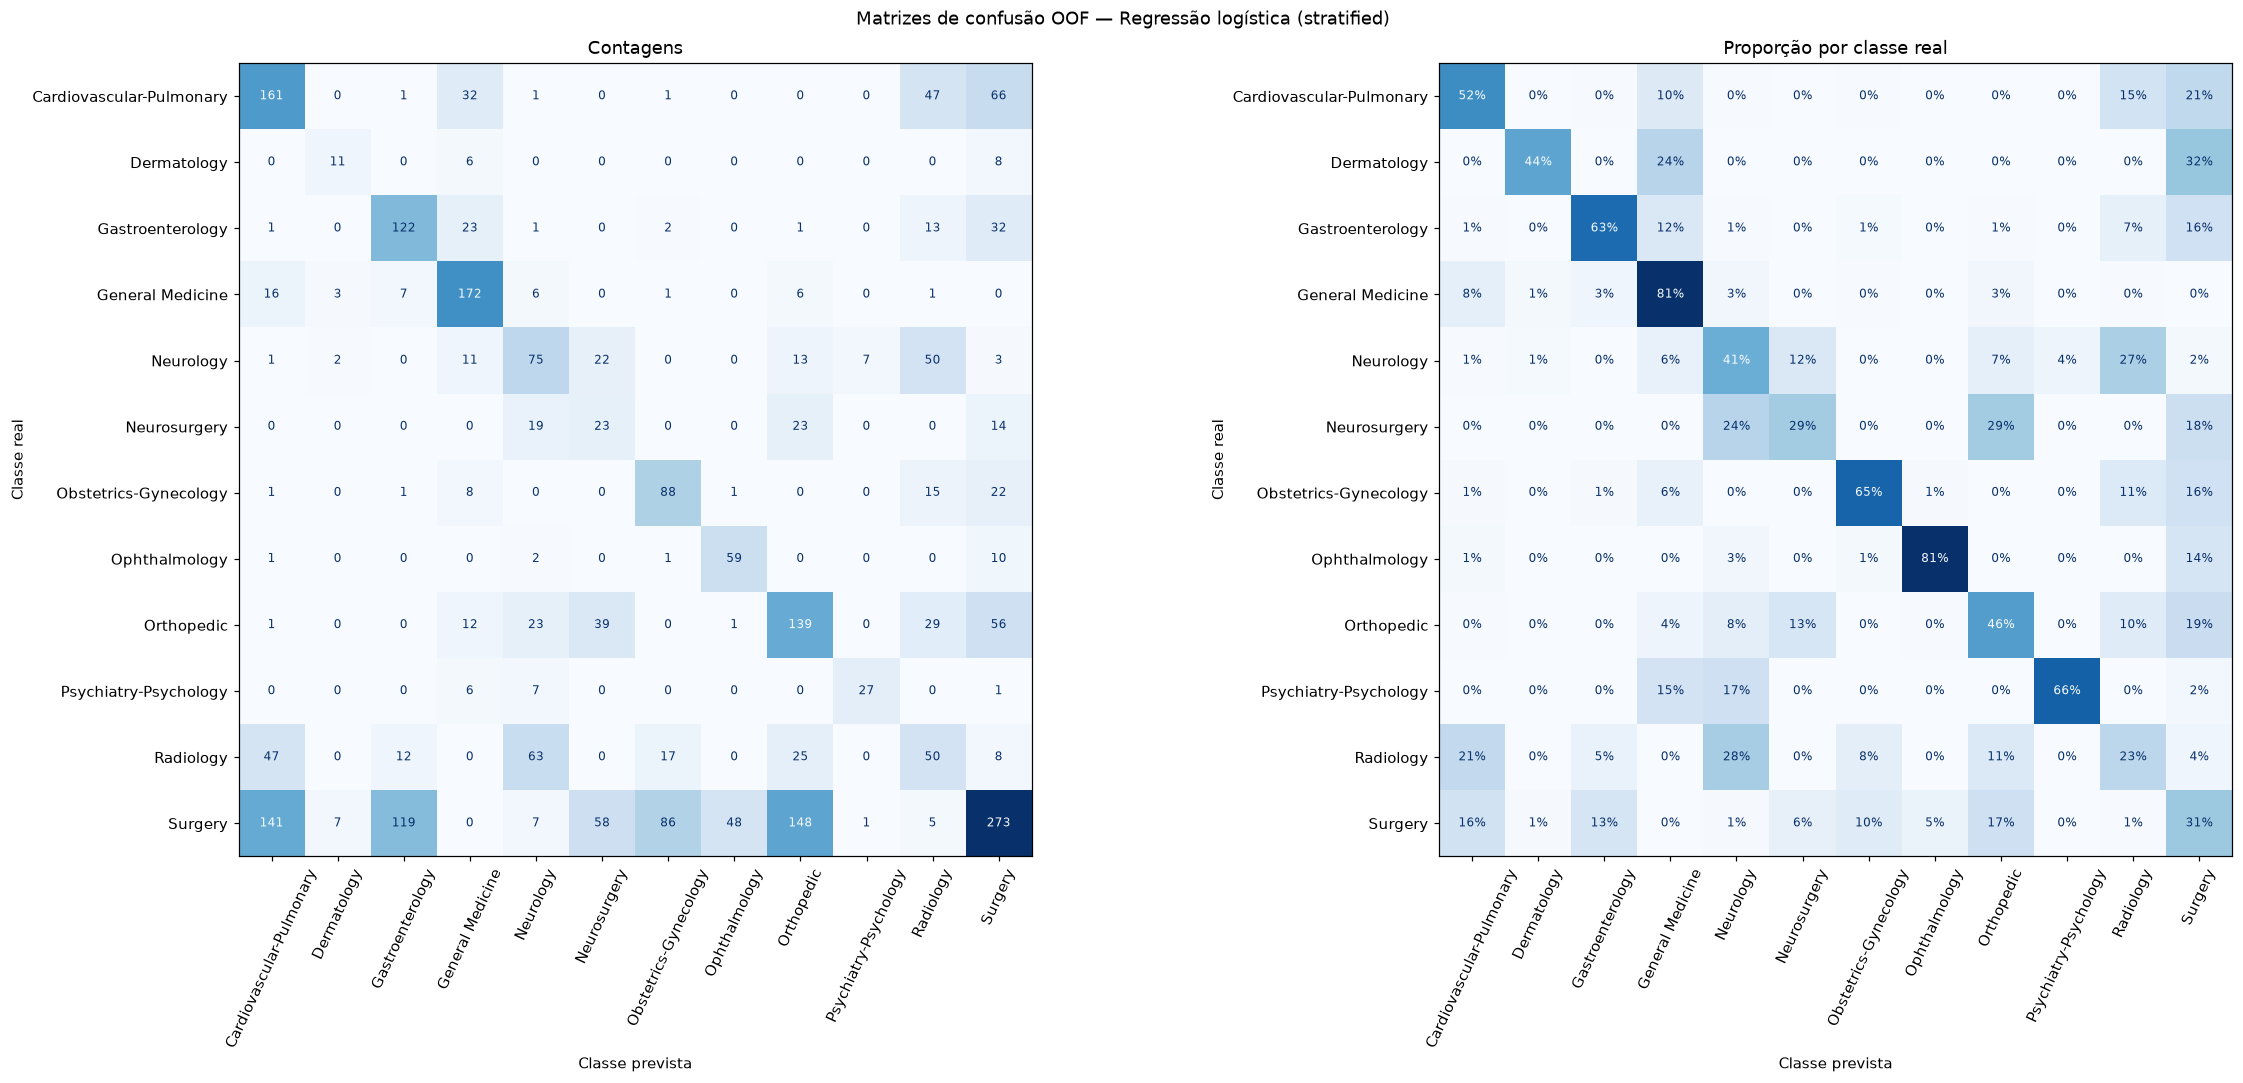

,classe_real,classe_prevista,casos,fração_da_classe_real
66,Surgery,Orthopedic,148,16.6%
59,Surgery,Cardiovascular-Pulmonary,141,15.8%
61,Surgery,Gastroenterology,119,13.3%
64,Surgery,Obstetrics-Gynecology,86,9.6%
5,Cardiovascular-Pulmonary,Surgery,66,21.4%
55,Radiology,Neurology,63,28.4%
63,Surgery,Neurosurgery,58,6.5%
49,Orthopedic,Surgery,56,18.7%
28,Neurology,Radiology,50,27.2%
65,Surgery,Ophthalmology,48,5.4%


In [13]:
cm_normalized = confusion_matrix(y, predicted, labels=CLASS_ORDER, normalize="true")
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, values, title, value_format in (
    (axes[0], cm, "Contagens", "d"),
    (axes[1], cm_normalized, "Proporção por classe real", ".0%"),
):
    ConfusionMatrixDisplay(values, display_labels=CLASS_ORDER).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=value_format, xticks_rotation=65
    )
    ax.set(title=title, xlabel="Classe prevista", ylabel="Classe real")
    for text in ax.texts:
        text.set_fontsize(8)
fig.suptitle(f"Matrizes de confusão OOF — {MAIN_MODEL} ({CV_MODE})")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "matrizes_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

confusion_rows = [
    {"classe_real": CLASS_ORDER[i], "classe_prevista": CLASS_ORDER[j],
     "casos": int(cm[i, j]), "fração_da_classe_real": float(cm_normalized[i, j])}
    for i, j in np.argwhere(cm > 0) if i != j
]
frequent_confusions = pd.DataFrame(confusion_rows, columns=[
    "classe_real", "classe_prevista", "casos", "fração_da_classe_real"
]).sort_values("casos", ascending=False)
display(frequent_confusions.head(12).style.format({"fração_da_classe_real": "{:.1%}"}))


## 12. Consultar os casos que o modelo errou

Cada exemplo abaixo foi previsto no fold onde era validação. O identificador
`record_id` permite encontrá-lo no leitor HTML. A indicação de rótulos em conflito
ajuda a distinguir erros do modelo de ambiguidades já presentes no dataset.
Os textos aparecem abreviados para manter o notebook legível.


In [14]:
validation_predictions = train[["record_id", "source_line_start", "source_line_end", LABEL]].copy()
validation_predictions = validation_predictions.rename(columns={LABEL: "classe_real"})
validation_predictions["classe_prevista"] = predicted
validation_predictions["correto"] = y.to_numpy() == predicted
validation_predictions["fold"] = fold_assignment
validation_predictions["grupo"] = groups.to_numpy()
validation_predictions["rotulos_em_conflito"] = audit["conflicting_labels"].to_numpy()
validation_predictions["description"] = train["description"].str.slice(0, 240)
validation_predictions["sample_name"] = train["sample_name"].str.slice(0, 120)
for name, values in oof_predictions.items():
    validation_predictions[f"previsão — {name}"] = values
errors = validation_predictions.loc[~validation_predictions["correto"]].copy()
print(f"Erros OOF: {len(errors)} / {len(y)} ({len(errors) / len(y):.1%})")
display(errors[[
    "record_id", "fold", "classe_real", "classe_prevista",
    "rotulos_em_conflito", "description", "sample_name",
]].head(12))


Erros OOF: 1469 / 2669 (55.0%)


,record_id,fold,classe_real,classe_prevista,rotulos_em_conflito,description,sample_name
1,2,4,Cardiovascular-Pulmonary,General Medicine,False,"The patient is 14 months old, comes in with a chief complaint of difficulty breathing.",Difficulty Breathing - ER Visit
3,4,3,Cardiovascular-Pulmonary,Radiology,True,Left lower extremity venous Doppler ultrasound,Lower Extremity Venous Doppler
4,5,4,Cardiovascular-Pulmonary,General Medicine,False,The patient was admitted after undergoing a drawn out process with a small bowel obstruction.,Discharge Summary - Respiratory Failure
5,6,3,Cardiovascular-Pulmonary,General Medicine,False,Abnormal EKG and rapid heart rate. The patient came to the emergency room. Initially showed atrial fibr...,Consult - Abnormal EKG
8,9,1,Cardiovascular-Pulmonary,Radiology,True,Right and Left carotid ultrasound,Ultrasound - Carotid - 1
9,10,2,Cardiovascular-Pulmonary,Radiology,True,"Chest pain, shortness of breath and cough, evaluate for pulmonary arterial embolism. CT angiography ches...",CT Angiography
14,15,1,Cardiovascular-Pulmonary,Surgery,True,Left heart catheterization and bilateral selective coronary angiography. Left ventriculogram was not perf...,Heart Catheterization & Angiography - 2
17,18,4,Cardiovascular-Pulmonary,Radiology,True,2-D Echocardiogram,2-D Echocardiogram - 2
22,23,2,Cardiovascular-Pulmonary,General Medicine,False,Chronic obstructive pulmonary disease (COPD) exacerbation and acute bronchitis.,COPD & Bronchitis - Discharge Summary
23,24,1,Cardiovascular-Pulmonary,Gastroenterology,True,"Left thoracotomy with drainage of pleural fluid collection, esophageal exploration and repair of esophage...",Thoracotomy & Esophageal Exploration


## 13. Guardar as métricas e treinar o modelo final

A avaliação terminou. Agora ajustamos uma Pipeline nova em **todos os casos de
treino** para gerar as previsões finais. As métricas continuam a ser as OOF;
não são recalculadas nas previsões deste modelo sobre os próprios dados de treino.

Guardamos os CSVs (separador `;`, UTF-8 com BOM), gráficos, parâmetros, hashes,
versões das bibliotecas e o modelo em `outputs/notebook/`. Uma nova execução
substitui os resultados dessa pasta.


In [15]:
comparison.to_csv(OUTPUT_DIR / "comparacao_modelos.csv", sep=";", encoding="utf-8-sig")
fold_metrics.to_csv(OUTPUT_DIR / "metricas_por_fold.csv", sep=";", encoding="utf-8-sig", index=False)
pd.Series(main_scores, name="valor").rename_axis("metrica").to_csv(
    OUTPUT_DIR / "metricas_globais.csv", sep=";", encoding="utf-8-sig"
)
per_class.to_csv(OUTPUT_DIR / "metricas_por_classe.csv", sep=";", encoding="utf-8-sig")
pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER).rename_axis("classe_real").to_csv(
    OUTPUT_DIR / "matriz_confusao.csv", sep=";", encoding="utf-8-sig"
)
pd.DataFrame(cm_normalized, index=CLASS_ORDER, columns=CLASS_ORDER).rename_axis("classe_real").to_csv(
    OUTPUT_DIR / "matriz_confusao_normalizada.csv", sep=";", encoding="utf-8-sig"
)
validation_predictions.to_csv(OUTPUT_DIR / "previsoes_validacao.csv", sep=";", encoding="utf-8-sig", index=False)
errors.to_csv(OUTPUT_DIR / "erros_validacao.csv", sep=";", encoding="utf-8-sig", index=False)
frequent_confusions.to_csv(OUTPUT_DIR / "confusoes_frequentes.csv", sep=";", encoding="utf-8-sig", index=False)
class_distribution.to_csv(OUTPUT_DIR / "distribuicao_classes.csv", sep=";", encoding="utf-8-sig")

final_model = clone(main_pipeline).fit(main_input, y)
main_fields = TEXT_FIELDS if MAIN_MODEL == "Regressão logística" else ("description",)
model_path = OUTPUT_DIR / "modelo.joblib"
joblib.dump({
    "model": final_model, "model_name": MAIN_MODEL,
    "fields": main_fields, "classes": CLASS_ORDER,
}, model_path)

experiment_metadata = {
    "main_model": MAIN_MODEL, "main_fields": list(main_fields),
    "logistic_regression_fields": list(TEXT_FIELDS),
    "cv_mode": CV_MODE, "n_folds": N_FOLDS, "seed": SEED,
    "compare_baselines": COMPARE_BASELINES,
    "tfidf": {"ngram_range": list(NGRAM_RANGE), "min_df": MIN_DF, "sublinear_tf": SUBLINEAR_TF},
    "logistic_regression": {"C": C, "class_weight": CLASS_WEIGHT, "max_iter": MAX_ITER},
    "naive_bayes": {"alpha": NB_ALPHA, "fit_prior": NB_FIT_PRIOR},
    "train_records": len(train), "classes": CLASS_ORDER,
    "versions": {"python": sys.version.split()[0], **versions},
    "source_sha256": original_hashes,
    "oof_metrics": {key: float(value) for key, value in main_scores.items()},
    "criteria": {"accuracy_strictly_above": MIN_ACCURACY, "each_class_f1_at_least": MIN_CLASS_F1},
    "meets_criteria_in_cv": bool(passes),
    "shared_groups_per_fold": split_summary["grupos_partilhados"].astype(int).tolist(),
}
(OUTPUT_DIR / "experiencia.json").write_text(
    json.dumps(experiment_metadata, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)
print(f"Modelo final treinado em {len(y)} casos: {model_path}")
print(f"Métricas e parâmetros exportados para {OUTPUT_DIR}")


Modelo final treinado em 2669 casos: D:\projetos\faculdade\LN\help-the-doctors\outputs\notebook\modelo.joblib
Métricas e parâmetros exportados para D:\projetos\faculdade\LN\help-the-doctors\outputs\notebook


## 14. Prever os 409 casos de teste e experimentar outros textos

O teste é lido com `read_test_cases`, que respeita os registos CSV sem cabeçalho
e as regras de reparação específicas do projeto. Os rótulos embutidos em células
malformadas ficam fora da entrada do modelo. A linha N de `results.txt` corresponde
ao registo CSV N, sem eliminar, reordenar ou juntar casos.

O ficheiro de previsões fica em `outputs/notebook/results.txt`. Para escrever
também o ficheiro usado pela submissão na raiz, define `WRITE_ROOT_RESULTS=True`
na configuração e volta a executar o notebook.


In [16]:
test_cases = read_test_cases(ROOT / "test_no_labels.csv")
test = pd.DataFrame(test_cases).reset_index(drop=True)
test_text = prepare_text(test, main_fields)
test_input = test_text if MAIN_MODEL == "Regressão logística" else text_input(test_text, main_fields)
test_predictions = [str(label) for label in final_model.predict(test_input)]
assert len(test_predictions) == len(test) == EXPECTED_TEST_CASES

results_path = OUTPUT_DIR / "results.txt"
write_results(results_path, test_predictions, test_cases)
if WRITE_ROOT_RESULTS:
    write_results(ROOT / "results.txt", test_predictions, test_cases)

test_preview = test[["case_id", "source_line_start", "source_line_end", "description"]].copy()
test_preview["description"] = test_preview["description"].str.slice(0, 240)
test_preview["classe_prevista"] = test_predictions
test_preview.to_csv(OUTPUT_DIR / "previsoes_teste.csv", sep=";", encoding="utf-8-sig", index=False)
display(test_preview.head(10))
display(pd.Series(test_predictions, name="classe").value_counts().rename("casos previstos").to_frame())
assert results_path.read_text(encoding="utf-8").splitlines() == test_predictions
for name, before_hash in original_hashes.items():
    assert sha256(ROOT / name) == before_hash, f"O original {name} foi alterado."

experiment_metadata["test_records"] = len(test)
experiment_metadata["results_file"] = results_path.relative_to(ROOT).as_posix()
experiment_metadata["write_root_results"] = WRITE_ROOT_RESULTS
(OUTPUT_DIR / "experiencia.json").write_text(
    json.dumps(experiment_metadata, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)
print(f"Guardadas {len(test_predictions)} previsões: {results_path}")
print("Os ficheiros originais mantêm os mesmos hashes. O teste não tem métricas por não ter rótulos.")


,case_id,source_line_start,source_line_end,description,classe_prevista
0,1,1,1,Left temporal craniotomy and removal of brain tumor.,Neurosurgery
1,2,2,2,"Left heart catheterization, left and right coronary angiography, left ventricular angiography, and interc...",Cardiovascular-Pulmonary
2,3,3,3,Status post left hip fracture and hemiarthroplasty. Rehab transfer as soon as medically cleared.,Orthopedic
3,4,4,4,Endovascular Brachytherapy (EBT),Radiology
4,5,5,5,Bilateral endoscopic proximal shunt revision and a distal shunt revision.,Surgery
5,6,6,6,Patient with a history of right upper pons and right cerebral peduncle infarction.,Neurology
6,7,7,7,Tracheostomy change. A #6 Shiley with proximal extension was changed to a #6 Shiley with proximal extensi...,Surgery
7,8,8,8,"Closing wedge osteotomy, fifth metatarsal with internal screw fixation, right foot.",Orthopedic
8,9,9,9,Laparoscopic right radical nephrectomy due to right renal mass.,Surgery
9,10,10,10,Tube Shunt - Ahmed valve model S2 implant with pericardial reinforcement - Sample/Template.,Ophthalmology


,casos previstos
classe,
Surgery,68
Cardiovascular-Pulmonary,54
Orthopedic,50
Gastroenterology,49
Neurology,35
General Medicine,33
Obstetrics-Gynecology,33
Radiology,27
Neurosurgery,25


Guardadas 409 previsões: D:\projetos\faculdade\LN\help-the-doctors\outputs\notebook\results.txt
Os ficheiros originais mantêm os mesmos hashes. O teste não tem métricas por não ter rótulos.


### Prever um texto novo com o modelo guardado

Substitui os textos do exemplo. O dicionário deve ter os campos selecionados;
campos sem conteúdo podem ficar com `""`. Esta célula mostra também como
carregar o modelo sem repetir o treino. As probabilidades são estimativas do
classificador; não representam certezas nem uma calibração verificada.


In [17]:
saved = joblib.load(OUTPUT_DIR / "modelo.joblib")
new_cases = pd.DataFrame([{
    "description": "Evaluation of chest pain and shortness of breath.",
    "sample_name": "Cardiology consultation",
    "transcription": "The patient reports chest pain. An echocardiogram was requested.",
}])
new_text = prepare_text(new_cases, saved["fields"])
new_input = new_text if saved["model_name"] == "Regressão logística" else text_input(new_text, saved["fields"])
new_prediction = saved["model"].predict(new_input)[0]
probabilities = saved["model"].predict_proba(new_input)[0]
top_classes = pd.Series(probabilities, index=saved["model"].classes_, name="probabilidade").nlargest(3)
print(f"Especialidade prevista: {new_prediction}")
display(top_classes.to_frame().style.format("{:.1%}"))

generated_files = sorted(path for path in OUTPUT_DIR.iterdir() if path.is_file())
display(pd.DataFrame({
    "ficheiro": [path.name for path in generated_files],
    "tamanho_KB": [round(path.stat().st_size / 1024, 1) for path in generated_files],
}))


Especialidade prevista: Cardiovascular-Pulmonary


,probabilidade
Cardiovascular-Pulmonary,64.3%
Radiology,5.2%
Surgery,4.6%


,ficheiro,tamanho_KB
0,comparacao_modelos.csv,0.7
1,confusoes_frequentes.csv,3.6
2,distribuicao_classes.csv,0.5
3,distribuicao_classes.png,53.1
4,erros_validacao.csv,433.9
5,experiencia.json,2.0
6,folds.csv,0.2
7,matriz_confusao.csv,0.7
8,matriz_confusao_normalizada.csv,2.1
9,matrizes_confusao.png,367.0
